In [1]:
import os
os.getcwd()

'C:\\Users\\WENDY OTIENO'

In [3]:
import pandas as pd
df=pd.read_csv('online_retail.csv', encoding='ISO-8859-1') # Load the data using the correct text encoding to prevent errors
df.head()   #Display the first 5 rows of the data



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
#Checking the size of my data set (rows and columns)
df.shape


(541909, 8)

In [7]:
#Checking on the info of the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
#Count exactly how many missing values are in each column.

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
#1. Drop Missing Customer IDs & Nulls

# 1. Drop rows where CustomerID is missing
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Fill any remaining missing Descriptions with 'Unknown'
df_clean['Description'] = df_clean['Description'].fillna('Unknown')

# 3. Check the results: every column should now show 0 nulls!
print("Missing values per column after cleaning:")
print(df_clean.isnull().sum())

Missing values per column after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [6]:
#Step 2: Remove Duplicate Rows

# Check for duplicate rows
duplicates_count = df_clean.duplicated().sum()
print(f"Found {duplicates_count:,} duplicate rows.")

# Drop the duplicate rows
df_clean = df_clean.drop_duplicates()
print(f"Rows remaining: {len(df_clean):,}")

Found 5,225 duplicate rows.
Rows remaining: 401,604


In [7]:
#Step 3: Handle Cancelled Orders & Negative Numbers

# Keep only orders with positive Quantity and positive UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Filter out any InvoiceNo that starts with 'C' (Cancelled)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Final clean dataset row count: {len(df_clean):,}")

Final clean dataset row count: 392,692


In [7]:
#Step 4: Fix InvoiceDate & Add a TotalSum Column

# 1. Convert InvoiceDate to proper datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 2. Add a TotalSum column (Quantity * UnitPrice)
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Preview the clean dataframe!
df_clean.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
# 1. Calculate overall business summary
total_revenue = df_clean['TotalSum'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
total_customers = df_clean['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

print("=== E-COMMERCE BUSINESS OVERVIEW ===")
print(f"Total Revenue:         ${total_revenue:,.2f}")
print(f"Total Orders Placed:   {total_orders:,}")
print(f"Unique Customers:     {total_customers:,}")
print(f"Average Order Value:   ${avg_order_value:,.2f}")
print("=" * 35)

# 2. Top 5 Best-Selling Products by Revenue
print("\n--- TOP 5 PRODUCTS BY REVENUE ---")
top_products = df_clean.groupby('Description')['TotalSum'].sum().sort_values(ascending=False).head(5)
print(top_products.apply(lambda x: f"${x:,.2f}"))

=== E-COMMERCE BUSINESS OVERVIEW ===
Total Revenue:         $8,300,065.81
Total Orders Placed:   22,190
Unique Customers:     4,372
Average Order Value:   $374.05

--- TOP 5 PRODUCTS BY REVENUE ---
Description
REGENCY CAKESTAND 3 TIER              $132,870.40
WHITE HANGING HEART T-LIGHT HOLDER     $93,823.85
JUMBO BAG RED RETROSPOT                $83,236.76
PARTY BUNTING                          $67,687.53
POSTAGE                                $66,710.24
Name: TotalSum, dtype: object


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure InvoiceDate is in datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create a 'YearMonth' column (e.g., '2011-01') for monthly trend tracking
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

# Create a 'DayOfWeek' column for weekly pattern analysis
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

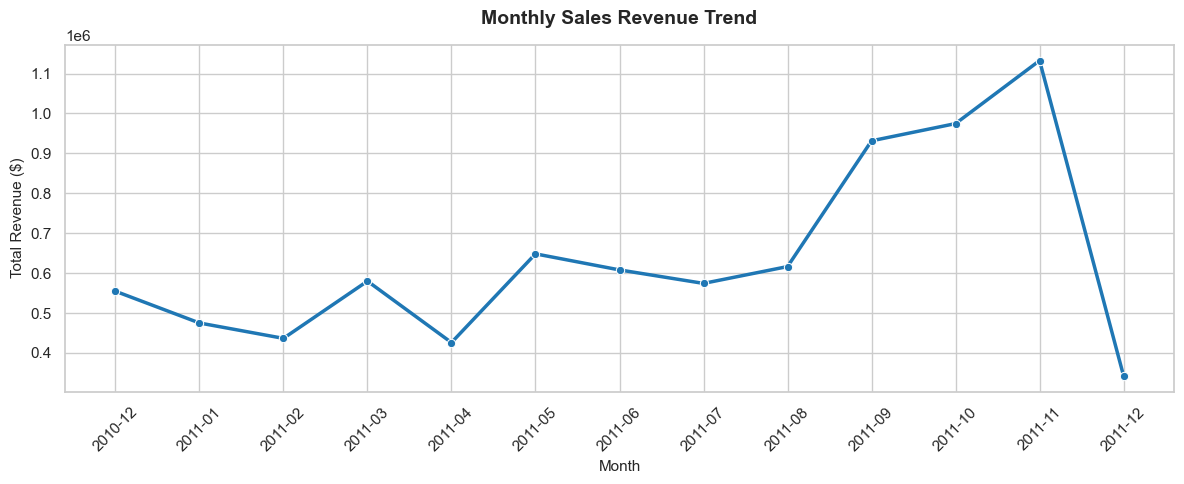

In [10]:
#2. Line Chart: Monthly Revenue Trend

# Aggregate sales by month
monthly_sales = df_clean.groupby('YearMonth')['TotalSum'].sum().reset_index()

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot line chart
sns.lineplot(
    data=monthly_sales, 
    x='YearMonth', 
    y='TotalSum', 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5
)

# Customizing titles and labels
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

# Rotate x-axis labels so dates don't overlap
plt.xticks(rotation=45)

# Ensure everything fits cleanly
plt.tight_layout()
plt.show()

C:\Users\WENDY OTIENO\AppData\Local\Temp\ipykernel_9600\3946313939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


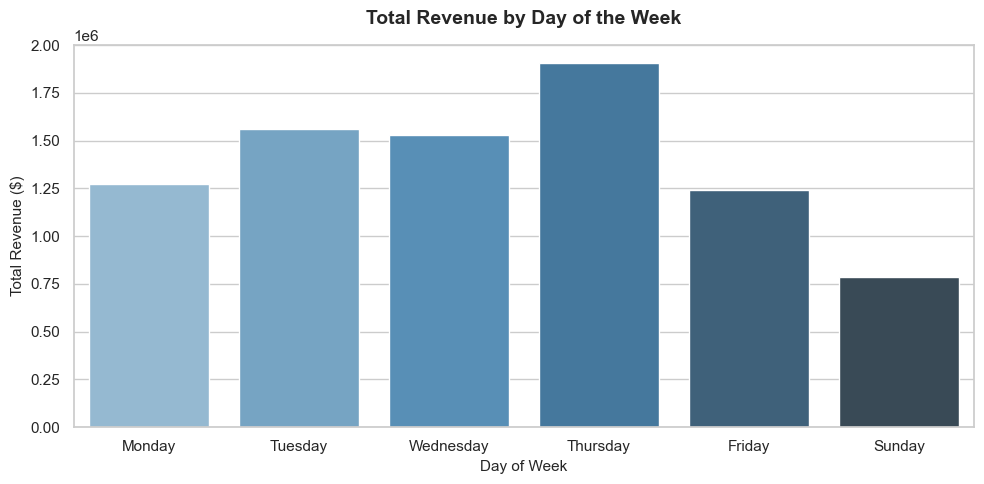

In [11]:
#3. Bar Graph: Revenue by Day of the Week

# Order days logically from Monday to Sunday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
daily_sales = df_clean.groupby('DayOfWeek')['TotalSum'].sum().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))

# Plot vertical bar graph
sns.barplot(
    data=daily_sales, 
    x='DayOfWeek', 
    y='TotalSum', 
    palette='Blues_d'
)

# Customizing titles and labels
plt.title('Total Revenue by Day of the Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Total Revenue ($)', fontsize=11)

plt.tight_layout()
plt.show()



In [12]:
#RFM (Recency, Frequency, Monetary) Customer Segmentation.
#RFM is one of the most practical analytics techniques in e-commerce. Instead of treating all customers equally, it groups them based on their actual buying behavior so you know who your VIPs are and who is about to churn.
#What RFM Measures:
#Recency (R): How many days ago was their last purchase? (Lower is better)

#Frequency (F): How many total orders did they place? (Higher is better)

#Monetary (M): How much total revenue did they generate? (Higher is better)

#Step 1: Calculate R, F, and M Metrics

import datetime as dt

# Set snapshot date to 1 day after the latest invoice date in the dataset
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate metrics by CustomerID
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalSum': 'sum'                                        # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [14]:
#Step 2: Assign RFM Scores (1 to 4)
#We use pd.qcut to divide customers into quartiles.

#For Recency, 4 is the top score (purchased most recently).

#For Frequency and Monetary, 4 is the top score (highest volume/spend).

# Create quartile scores
r_labels = [4, 3, 2, 1]  # Reverse for Recency: lower days = higher score
f_labels = [1, 2, 3, 4]
m_labels = [1, 2, 3, 4]

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
# Use rank(method='first') to handle duplicates in low frequency counts gracefully
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

# Combine scores into a single RFM Segment string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

rfm.head()



,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346.0,326,2,0.00,1,2,1,121,4
1,12347.0,2,7,4310.00,4,4,4,444,12
2,12348.0,75,4,1797.24,2,3,4,234,9
3,12349.0,19,1,1757.55,3,1,4,314,8
4,12350.0,310,1,334.40,1,1,2,112,4


In [15]:
#Step 3: Group Customers into Named Segments
#Now we group individual scores into actionable business categories:

def segment_customer(df):
    if df['RFM_Score'] >= 10:
        return 'VIP / Champions'
    elif (df['RFM_Score'] >= 7) and (df['RFM_Score'] < 10):
        return 'Loyal Customers'
    elif (df['RFM_Score'] >= 5) and (df['RFM_Score'] < 7):
        return 'At Risk / Need Attention'
    else:
        return 'Lost Customers'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# Count customers per segment
segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']
segment_counts

,Segment,Customer Count
0,Loyal Customers,1301
1,VIP / Champions,1276
2,At Risk / Need Attention,992
3,Lost Customers,803


C:\Users\WENDY OTIENO\AppData\Local\Temp\ipykernel_9600\2965815282.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Segment', y='Customer Count', palette='rocket')


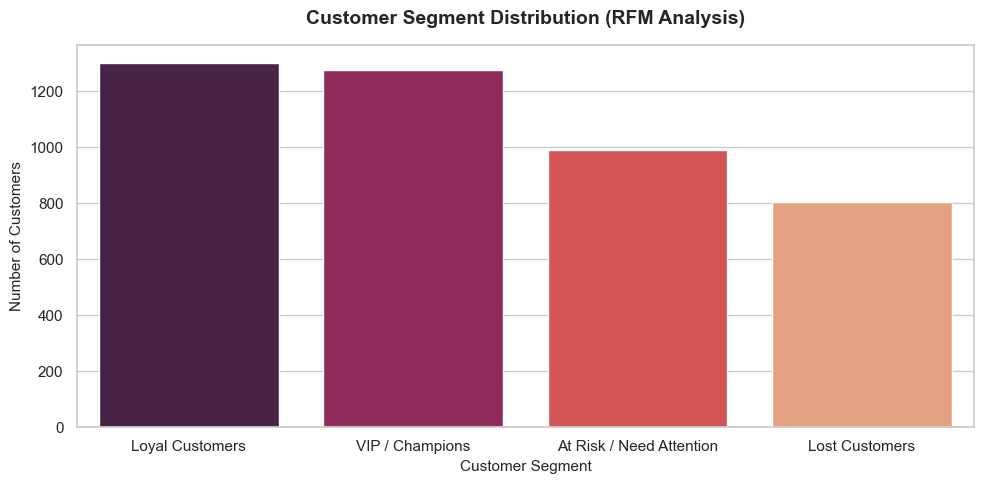

In [16]:
#Step 4: Visualize Your Customer Breakdown
#Generate a bar graph of your customer segments:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_counts, x='Segment', y='Customer Count', palette='rocket')

plt.title('Customer Segment Distribution (RFM Analysis)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
#How can I calculate what percentage of total company revenue comes from VIPs vs other segments?
#To calculate the revenue contribution per segment, we need to merge our rfm table back with our main df_clean dataframe (or group the Monetary values already calculated in rfm).
#Since Monetary in the rfm table already represents each customer's total historical spend, we can directly sum Monetary by Customer_Segment!
#calculate total spend, percentage contribution, and visualize it with a pie chart.

#Step 1: Calculate Revenue Breakdown Table
# Group spend by segment
segment_revenue = rfm.groupby('Customer_Segment')['Monetary'].sum().reset_index()

# Calculate percentage of total revenue
total_monetary = segment_revenue['Monetary'].sum()
segment_revenue['Revenue_Share_%'] = (segment_revenue['Monetary'] / total_monetary) * 100

# Sort by revenue descending
segment_revenue = segment_revenue.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

# Format for clean display
segment_revenue_display = segment_revenue.copy()
segment_revenue_display['Monetary'] = segment_revenue_display['Monetary'].apply(lambda x: f"${x:,.2f}")
segment_revenue_display['Revenue_Share_%'] = segment_revenue_display['Revenue_Share_%'].apply(lambda x: f"{x:.2f}%")

segment_revenue_display


,Customer_Segment,Monetary,Revenue_Share_%
0,VIP / Champions,"$6,460,340.10",77.83%
1,Loyal Customers,"$1,282,791.00",15.46%
2,At Risk / Need Attention,"$403,900.57",4.87%
3,Lost Customers,"$153,034.14",1.84%


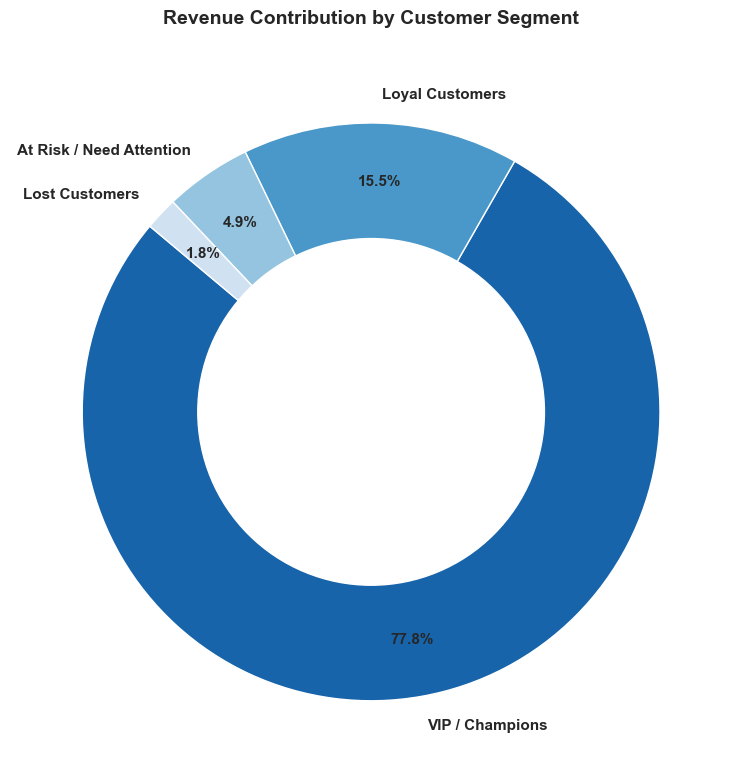

In [18]:
#Step 2: Visualize Contribution with a Donut Chart
#A donut chart clearly shows how heavily reliant the business is on its top tier (VIPs and Loyal customers):

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

# Define clean color palette
colors = sns.color_palette('Blues_r', len(segment_revenue))

# Create Donut Chart
plt.pie(
    segment_revenue['Monetary'], 
    labels=segment_revenue['Customer_Segment'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.80,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

# Draw white circle in center to make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [19]:
#How do I export the final cleaned dataset and RFM segments to CSV files for Excel or Tableau?
#1. Export the Cleaned Transactional Dataset
# Export cleaned transactions to CSV
df_clean.to_csv('cleaned_online_retail.csv', index=False)
print("Cleaned transactions exported successfully!")

Cleaned transactions exported successfully!


In [20]:
#2. Export the RFM Customer Summary
#This exports one row per customer with their Recency, Frequency, Monetary values, RFM scores, and assigned Customer_Segment.

# Export RFM metrics and segments to CSV
rfm.to_csv('rfm_segmentation_summary.csv', index=False)
print("RFM summary exported successfully!")

RFM summary exported successfully!


In [21]:
#3. Export a Master Combined Dataset (Recommended for Tableau/Power BI)
#If you want to build dashboards in Excel or Tableau where you can slice individual product purchases by customer segment, merge rfm back into df_clean:

# Merge customer segment back into full transaction dataset
df_master = df_clean.merge(
    rfm[['CustomerID', 'Customer_Segment', 'RFM_Score', 'RFM_Segment']], 
    on='CustomerID', 
    how='left'
)

# Export master dataset
df_master.to_csv('online_retail_with_segments.csv', index=False)
print("Master combined dataset exported successfully!")

Master combined dataset exported successfully!


In [3]:
import os
import shutil

# Ensure we are in the main project root folder
os.chdir('C:/Users/WENDY OTIENO/ecommerce-rfm-analysis')

# 1. Remove the accidentally created nested .git folder inside notebooks/
notebooks_git = os.path.join('notebooks', '.git')
if os.path.exists(notebooks_git):
    shutil.rmtree(notebooks_git)

# 2. Fix double file extensions if present
if os.path.exists('requirements.txt.txt'):
    os.rename('requirements.txt.txt', 'requirements.txt')

if os.path.exists('.gitignore.gitignore'):
    os.rename('.gitignore.gitignore', '.gitignore')

# 3. Clean Git index and re-add everything cleanly
!git rm -r --cached notebooks
!git add .
!git commit -m "Fix file extensions and clean up notebooks directory structure"
!git push -f origin main

PermissionError: [WinError 5] Access is denied: 'notebooks\\.git\\objects\\04\\a298a5549934866e66f5665b2d221f9b34411e'